In [59]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [60]:
class CICFilter:
    def __init__(self, R, M, N):
        """
        Initialize the CIC Decimation Filter.
        
        Parameters:
        R (int): Decimation factor (rate change)
        M (int): Differential delay (usually 1 or 2)
        N (int): Number of stages (order)
        """
        self.R = R
        self.M = M
        self.N = N

    def get_transfer_function(self):
        """
        Generates the numerator (b) and denominator (a) coefficients.
        H(z) = [ (1 - z^(-RM)) / (1 - z^-1) ]^N
        """
        # Numerator: (1 - z^(-RM))^N
        b_single = np.zeros(self.R * self.M + 1)
        b_single[0] = 1.0
        b_single[-1] = -1.0
        
        b = np.array([1.0])
        for _ in range(self.N):
            b = np.convolve(b, b_single)

        # Denominator: (1 - z^-1)^N
        a_single = np.array([1.0, -1.0])
        a = np.array([1.0])
        for _ in range(self.N):
            a = np.convolve(a, a_single)

        return b, a

    def plot_frequency_response(self, fs=1.0, points=8192,f_signal=10000):
        """
        Plots the magnitude response using the exact analytical formula.
        We avoid using scipy.signal.freqz(b, a) directly here because large 
        polynomial expansions of CIC filters suffer from floating-point instability.
        """
        # Frequency vector (start slightly above 0 to avoid divide-by-zero at DC)
        f = np.linspace(1e-6, fs / 2, points) 
        w = 2 * np.pi * f / fs

        # Analytical magnitude response formula for a CIC filter
        mag = np.abs((np.sin(w * self.R * self.M / 2) / np.sin(w / 2)) ** self.N)
        # Normalize DC gain to 0 dB (Theoretical max DC gain is (R*M)^N)
        dc_gain = (self.R * self.M) ** self.N
        mag_db = 20 * np.log10(mag / dc_gain + 1e-10)

        # f_slope = np.array([(1.4303*fs)/(self.R), fs]) 
        # start_db = -13.36*self.N
        # mag_slope = start_db - (20 * self.N) * np.log10(f_slope / f_slope[0])

        # # Plotting
        # plt.figure(figsize=(10, 6))
        # plt.xscale('log')
        # plt.plot(f, mag_db, label=f'CIC (R={self.R}, M={self.M}, N={self.N})', color='blue')
        
        # plt.title('CIC Decimator Frequency Response')
        # plt.xlabel(f'Frequency (Hz) [Assuming Fs = {fs} Hz]')
        # plt.ylabel('Normalized Magnitude (dB)')
        # plt.grid(True, which='both', linestyle='--', alpha=0.7)
        
        # # Limit axes for standard filter visualization
        # plt.xlim(1, fs)
        # plt.ylim(-200, 5) 

        # # Highlight the first null (occurs at Fs / (R*M))
        # null_freq = fs / (self.R * self.M)
        # plt.axvline(null_freq, color='red', linestyle=':', label=f'First Null ({null_freq:.2f} Hz)')
        # plt.plot(f_slope, mag_slope, color='red', linestyle='--', linewidth=2, label=f'Asymptotic Rolloff (-{20*self.N} dB/dec)')
        # nqst_freq = null_freq/2
        # plt.axvline(nqst_freq, color='purple', linestyle=':', label=f'Nqst freq ({nqst_freq:.2f} Hz)')

        # plt.legend(loc='upper right')
        # plt.tight_layout()
        # plt.show()

        sinc_term = np.sin(w * self.R * self.M / 2.0) / np.sin(w / 2.0)
        sinc_term[w == 0] = self.R * self.M
        tau_samples = self.N * (self.R * self.M - 1) / 2.0
        H_cic = (sinc_term ** self.N) * np.exp(-1j * w * tau_samples)
        
        phase_rad = np.unwrap(np.angle(H_cic))
        phase_deg = np.rad2deg(phase_rad)
        
        f_main_khz = f
        fs_khz = fs

        print(f'At {f_signal} Hz magnitude: {mag_db[np.argmin(np.abs(f_main_khz - f_signal))]}')
        print(f'At {f_signal} Hz Phase: {phase_deg[np.argmin(np.abs(f_main_khz - f_signal))]}')
        # Define stage configurations: (mag_data, decimation_factor, f_slope_start, start_db, title)
        stages = [
            (
                mag_db,
                self.R,
                (1.4303 * fs_khz) / self.R,
                -13.36 * self.N,
                "Stage 1 Response",
            )
        ]

        # 2. Setup 5 stacked subplots with shared X axes for aligned zooming
        fig, axes = plt.subplots(3, 1, figsize=(14, 20), sharex=False)
        plt.subplots_adjust(hspace=0.35)

        # 3. Plot Stages 1 to 3 Magnitude
        for idx, (mag, R_total, f_start, start_db, title) in enumerate(stages):
            ax = axes[idx]
            f_nyq_khz = fs_khz / (2 * R_total)

            # Plot transfer function magnitude
            ax.plot(f_main_khz,mag,color="#1f77b4",linewidth=1.5,label="Magnitude (dB)",)

            # Plot asymptotic rolloff line
            f_slope = np.array([f_start, fs_khz/2])
            mag_slope = start_db - (20 * self.N) * np.log10(f_slope / f_slope[0] )
            ax.plot(f_slope, mag_slope, color="#d62728", linestyle="--", linewidth=2, label=f"Asymptotic Rolloff (-{20 * self.N} dB/dec)",)

            # Nyquist frequency marker
            ax.axvline(f_nyq_khz, color="#9467bd", linestyle=":", linewidth=2, label=f"Nyquist Freq ({f_nyq_khz:.2f} kHz)",)

            ax.set_xscale("log")
            ax.set_ylabel("Magnitude (dB)")
            ax.set_title(title, fontweight="bold")
            ax.grid(True, which="both", linestyle="--", alpha=0.5)
            ax.legend(loc="lower left", framealpha=0.9)

        # 4. Plot Stage 3 Unwrapped Phase
        ax_phase = axes[1]
        ax_phase.plot(f_main_khz,phase_deg,color="#2ca02c",linewidth=1.5,label="Phase (Degrees)",)
        f_nyq_s3 = fs_khz / (2 * self.R)
        ax_phase.axvline(f_nyq_s3,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_s3:.2f} kHz)",)

        ax_phase.set_xscale("log")
        ax_phase.set_xlabel("Frequency (kHz)")
        ax_phase.set_ylabel("Phase (deg)")
        ax_phase.set_ylim(-5000, 1000)
        ax_phase.set_title("Stage 3 Phase Response", fontweight="bold")
        ax_phase.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_phase.legend(loc="lower left", framealpha=0.9)

        # 5. Plot Passband Ripple Zoom (Plot 5 - Hz Scale)
        ax_zoom = axes[2]
        f_nyq_hz = fs_khz / (2 * self.R)

        ax_zoom.plot(f_main_khz,mag_db,color="#1f77b4",linewidth=1.5,label="Passband Detail",)
        ax_zoom.axvline(f_nyq_hz,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_hz:.2f} Hz)",)

        ax_zoom.set_xscale("log")
        ax_zoom.set_ylim(-1, 1)
        ax_zoom.set_xlabel("Frequency (Hz)")
        ax_zoom.set_ylabel("Magnitude (dB)")
        ax_zoom.set_title("Stage 3 Passband Zoom", fontweight="bold")
        ax_zoom.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_zoom.legend(loc="lower left", framealpha=0.9)

        plt.tight_layout()
        plt.show()

    def calculate_clean_peak_to_peak(self, signal_data, sample_indices, transient_cutoff=15000):
        """
        Calculates the true peak-to-peak value by ignoring the initial transient.
        
        Parameters:
        - signal_data: array-like, the amplitude values of your stage output
        - sample_indices: array-like, the index array (x-axis in your plot)
        - transient_cutoff: int, index value below which data is discarded (default 15,000)
        """
        # Convert inputs to numpy arrays
        signal_data = np.asarray(signal_data)
        sample_indices = np.asarray(sample_indices)
        
        # Mask out everything during the initial settling period (X < transient_cutoff)
        steady_state_mask = sample_indices > transient_cutoff
        clean_signal = signal_data[steady_state_mask]
        # print(len(clean_signal))
        # Calculate true peak-to-peak amplitude
        p2p_value = np.max(clean_signal) - np.min(clean_signal)
        return round(p2p_value,6), round(np.max(clean_signal),6), round(np.min(clean_signal),6)

    def process(self, x):
        """
        Processes an input bitstream using the efficient Integrator-Comb cascade.
        This handles the downsampling (decimation) internally.
        """
        # Use 64-bit integer to simulate hardware register wrap-around 
        # and prevent catastrophic overflow typical in standard float math.
        x = np.asarray(x, dtype=np.int64) 

        # 1. Integrator Stages (runs at the high input sample rate)
        current_signal = x.copy()
        for _ in range(self.N):
            current_signal = np.cumsum(current_signal)

        # 2. Decimation (Downsampling by R)
        decimated_signal = current_signal[::self.R]

        # 3. Comb Stages (runs at the lower output sample rate)
        comb_out = decimated_signal.copy()
        for _ in range(self.N):
            # Apply differential delay of M
            delayed = np.zeros_like(comb_out)
            delayed[self.M:] = comb_out[:-self.M]
            comb_out = comb_out - delayed
        return comb_out

In [61]:
# Define parameters
R = 512   # Decimation factor
M = 1    # Differential delay
N = 4    # Number of stages (Order)
f_signal = 10000          # Baseband sine wave frequency (Hz)
fs_base = 25000          # Nyquist output rate (Hz)
fs_high = fs_base * R   # High oversampled clock rate (Hz)
duration = 0.005         # 100 us simulation duration
phi_deg = 90.0
phi_rad = np.deg2rad(phi_deg)  # or np.radians(phi_deg)

# Instantiate the filter
cic_filter = CICFilter(R=R, M=M, N=N)

At 10000 Hz magnitude: -9.680299589357574
At 10000 Hz Phase: -287.43821862424534


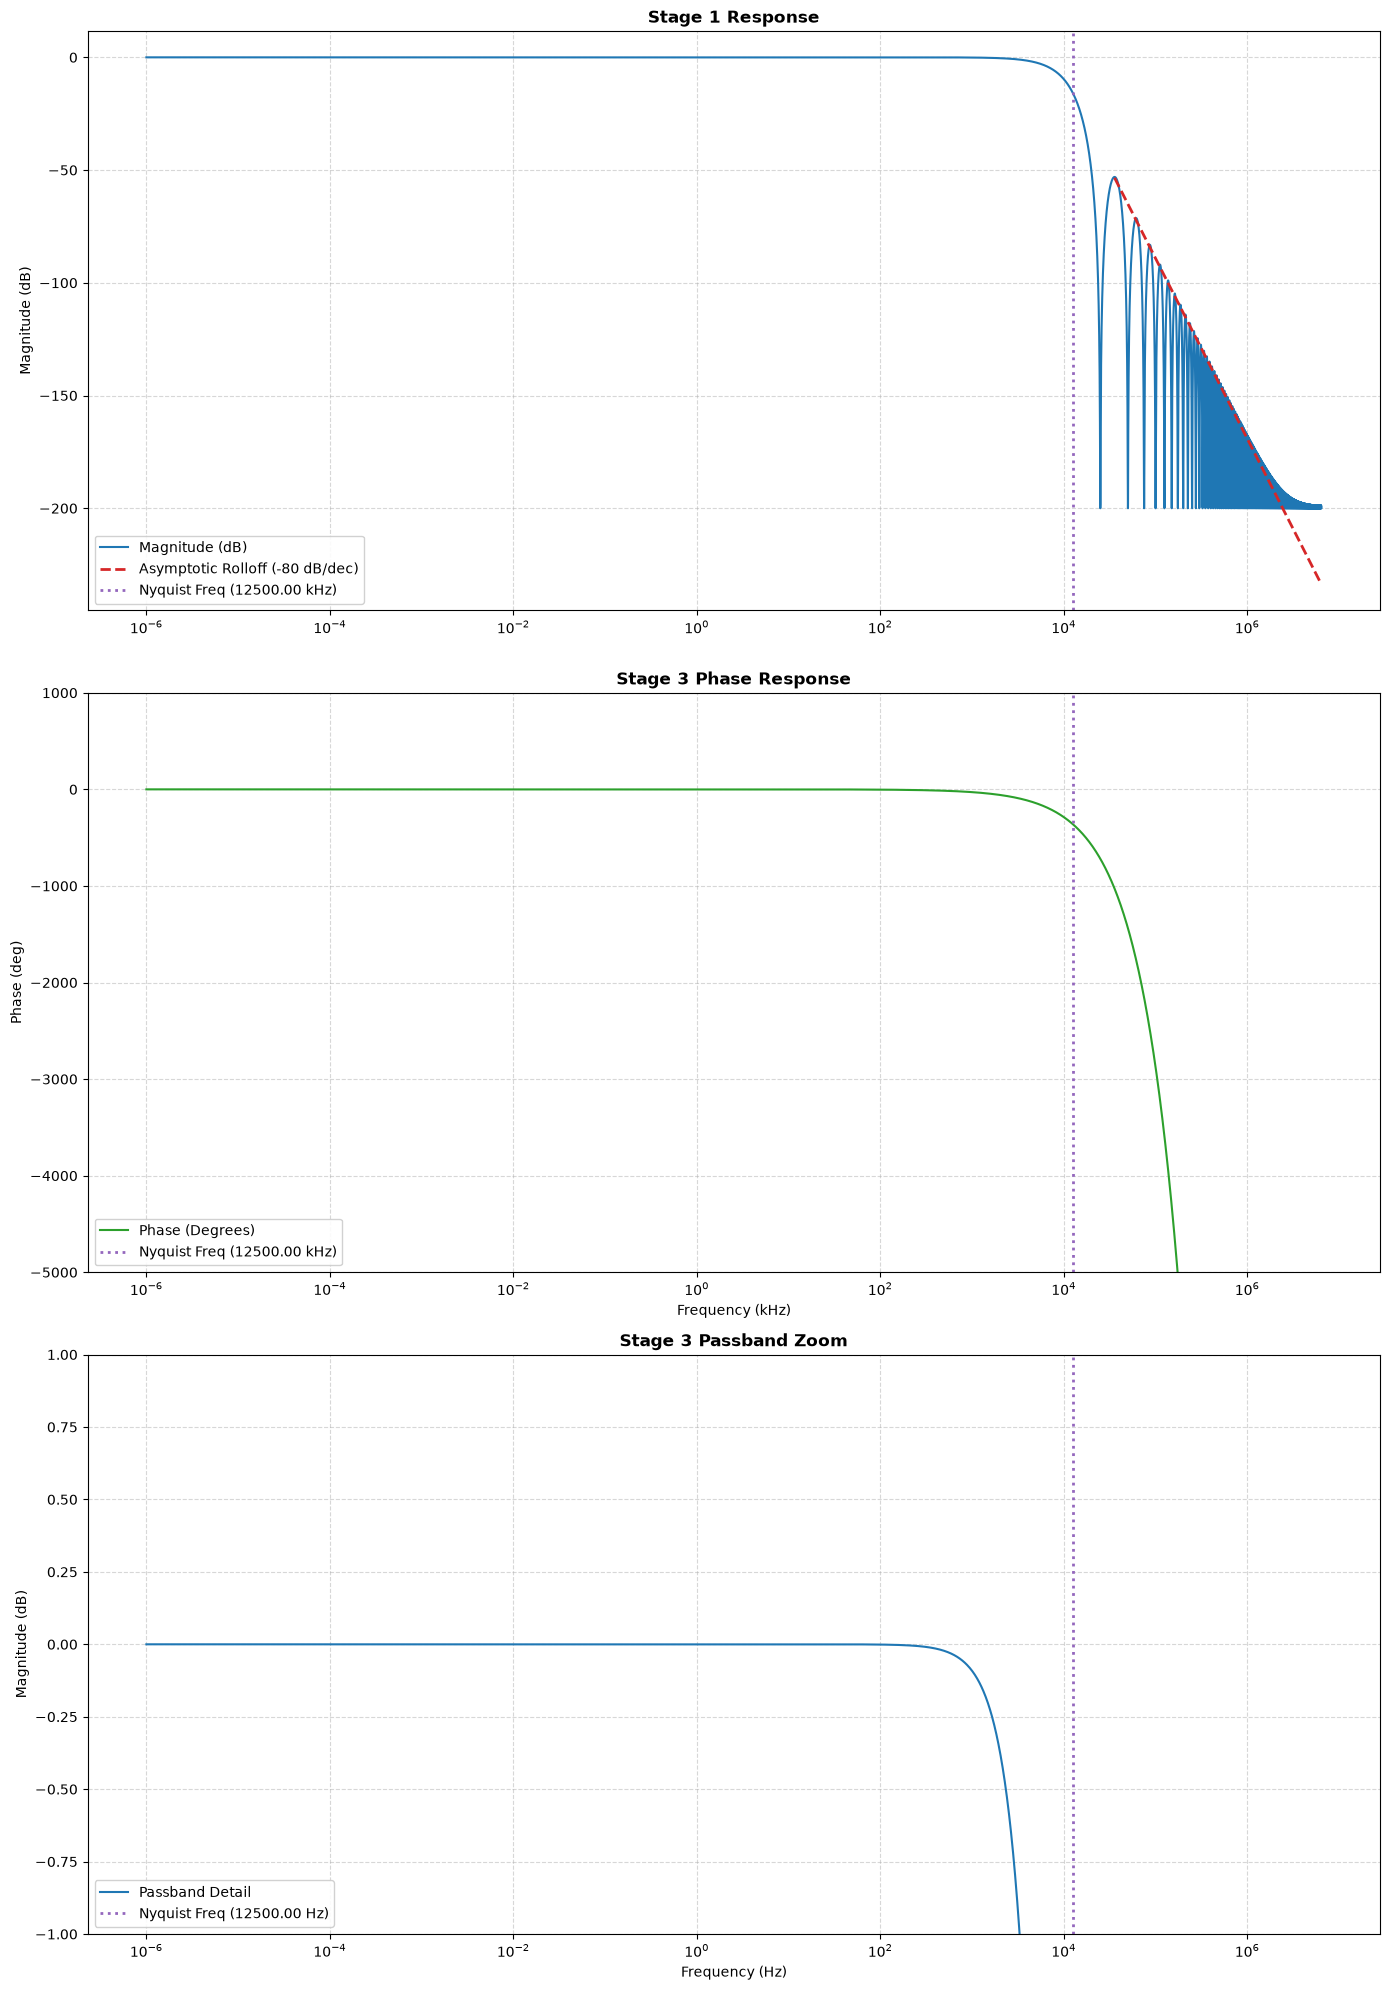

In [62]:
cic_filter.plot_frequency_response(fs=fs_high, points=400000, f_signal=f_signal)

In [63]:
b, a = cic_filter.get_transfer_function()
print("Numerator (b) length:", len(b))
print("Denominator (a) length:", len(a))

Numerator (b) length: 2049
Denominator (a) length: 5


In [64]:
class DeltaSigmaModulator:
    def __init__(self, order=1, output_format='bipolar'):
        """
        1-Bit Delta-Sigma Modulator (PDM Bitstream Generator).
        
        Parameters:
        order (int): Modulator order (1 or 2).
        output_format (str): 'bipolar' for output values in {-1, +1}
                             'unipolar' for output values in {0, 1}
        """
        if order not in [1, 2, 3]:
            raise ValueError("Order must be either 1 or 2 or 3.")
        if output_format not in ['bipolar', 'unipolar']:
            raise ValueError("output_format must be 'bipolar' or 'unipolar'.")
            
        self.order = order
        self.output_format = output_format

    # def modulate(self, input_signal):
    #     """
    #     Converts a high-resolution input signal into a 1-bit PDM stream.
        
    #     Parameters:
    #     input_signal (array-like): Input array. 
    #                               If 'bipolar', values should be scaled to [-1.0, +1.0].
    #                               If 'unipolar', values should be scaled to [0.0, 1.0].
        
    #     Returns:
    #     np.ndarray (int64): 1-bit bitstream array.
    #     """
    #     x = np.asarray(input_signal, dtype=np.float64)
    #     N_samples = len(x)
    #     bitstream = np.zeros(N_samples, dtype=np.int64)
        
    #     # Internal state variables for integrators
    #     v1 = 0.0
    #     v2 = 0.0
    #     v3 = 0.0
    #     feedback = 0.0

    #     if self.output_format == 'bipolar':
    #         # Expected input range: [-1, +1]
    #         for n in range(N_samples):
    #             # Delta stage (error calculation) & Sigma stage (integrators)
    #             if self.order == 1:
    #                 v1 = v1 + (x[n] - feedback)
    #                 quantizer_in = v1
    #             elif self.order == 2:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 quantizer_in = v2
    #             elif self.order == 3:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 v3 = v3 + (v2 - feedback)
    #                 quantizer_in = v3

    #             # 1-bit Quantizer (Threshold at 0)
    #             bitstream[n] = 1 if quantizer_in >= 0 else -1
    #             feedback = float(bitstream[n])

    #     elif self.output_format == 'unipolar':
    #         # Expected input range: [0, 1]
    #         for n in range(N_samples):
    #             if self.order == 1:
    #                 v1 = v1 + (x[n] - feedback)
    #                 quantizer_in = v1
    #             elif self.order == 2:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 quantizer_in = v2
    #             elif self.order == 3:
    #                 v1 = v1 + (x[n] - feedback)
    #                 v2 = v2 + (v1 - feedback)
    #                 v3 = v3 + (v2 - feedback)
    #                 quantizer_in = v3

    #             # 1-bit Quantizer (Threshold at 0.5)
    #             bitstream[n] = 1 if quantizer_in >= 0.5 else 0
    #             feedback = float(bitstream[n])

    def modulate(self, input_signal):
        x = np.asarray(input_signal, dtype=np.float64)
        N_samples = len(x)
        bitstream = np.zeros(N_samples, dtype=np.int64)
        
        # State variables for 3 integrators
        v1, v2, v3 = 0.0, 0.0, 0.0

        if self.output_format == 'bipolar':
            # Signal Range: [-0.6, +0.6]
            feedback = 0.0
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    # Textbook 3rd-Order CIFF Loop Coefficients
                    # Integrator gains: a1=0.5, a2=0.5, a3=0.5
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    # Feedforward weights: c1=1.0, c2=0.6, c3=0.15
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer (Threshold at 0)
                bit = 1 if quantizer_in >= 0 else -1
                bitstream[n] = bit
                feedback = float(bit)

        elif self.output_format == 'unipolar':
            # Signal Range: [0.1, 0.9] (Centered at 0.5)
            feedback = 0.5
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer
                bit = 1 if quantizer_in >= 0 else 0
                bitstream[n] = bit
                feedback = 1.0 if bit == 1 else 0.0

        return bitstream

        # return bitstream

# class DeltaSigmaModulator:
#     def __init__(self, order=3, osr=64, output_format='bipolar', opt=1, H_inf=1.5):
#         """
#         Parameterizable Delta-Sigma Modulator powered by python-deltasigma.
        
#         Parameters:
#         order (int): Modulator/NTF order (1, 2, 3, 4, 5, etc.)
#         osr (int): Oversampling Ratio (Decimation factor R)
#         output_format (str): 'bipolar' ({-1, +1}) or 'unipolar' ({0, 1})
#         opt (int): NTF zero optimization (0 = all zeros at z=1, 1 = optimized zeros in signal band)
#         H_inf (float): Maximum NTF gain (Lee's criterion stability limit, default 1.5)
#         """
#         self.order = order
#         self.osr = osr
#         self.output_format = output_format
        
#         # 1. Synthesize an optimal Noise Transfer Function (NTF) using python-deltasigma
#         # This guarantees stability for high-order loops (like 3rd order)
#         self.ntf = ds.synthesizeNTF(order=order, OSR=osr, opt=opt, H_inf=H_inf)

#     def modulate(self, input_signal):
#         """
#         Converts high-resolution input array into a 1-bit PDM stream.
        
#         Parameters:
#         input_signal (array-like): Input signal.
#                                   For 'bipolar': range within [-0.6, +0.6]
#                                   For 'unipolar': range within [0.2, 0.8]
        
#         Returns:
#         np.ndarray (int64): 1-bit bitstream array.
#         """
#         u = np.asarray(input_signal, dtype=np.float64)
        
#         if self.output_format == 'unipolar':
#             # python-deltasigma expects [-1, +1] bipolar signals for 2-level quantizers.
#             # Convert input [0, 1] range to [-1, +1] range for simulation
#             u_bipolar = 2.0 * u - 1.0
            
#             # 2. Simulate the DSM using python-deltasigma engine (nlev = 2 levels)
#             v, xn, xmax, y = ds.simulateDSM(u_bipolar, self.ntf, nlev=2)
            
#             # Map output back from {-1, +1} to {0, 1}
#             bitstream = np.where(v >= 0, 1, 0).astype(np.int64)
            
#         else: # 'bipolar'
#             # 2. Simulate 1-bit DSM directly
#             v, xn, xmax, y = ds.simulateDSM(u, self.ntf, nlev=2)
#             bitstream = np.round(v).astype(np.int64)
            
#         return bitstream


In [65]:
t_high = np.arange(0, duration, 1.0 / fs_high)
input_sine = 0.5 + 0.001 * np.sin(2 * np.pi * f_signal * t_high + phi_rad)

# plt.figure(figsize=(10, 6))
# plt.plot(t_high, input_sine, label=f'sine wave', color='blue')

# plt.title('Sine wave')
# plt.xlabel(f'time in sec')
# # plt.ylabel('Normalized Magn')
# plt.grid(True, which='both', linestyle='--', alpha=0.7)

# # Limit axes for standard filter visualization
# plt.xlim(0, duration)
# plt.ylim(-2, 2) 

In [66]:
dsm = DeltaSigmaModulator(order=3, output_format='unipolar')
bitstream = dsm.modulate(input_sine)

In [67]:
cic_output_raw = cic_filter.process(bitstream)
dc_gain = (R * M) ** N
cic_output_scaled = cic_output_raw / dc_gain

DC Offset:     0.500000 V
Positive Peak: 0.500328 V
Negative Peak: 0.499672 V
True Peak-Peak:0.000656 V


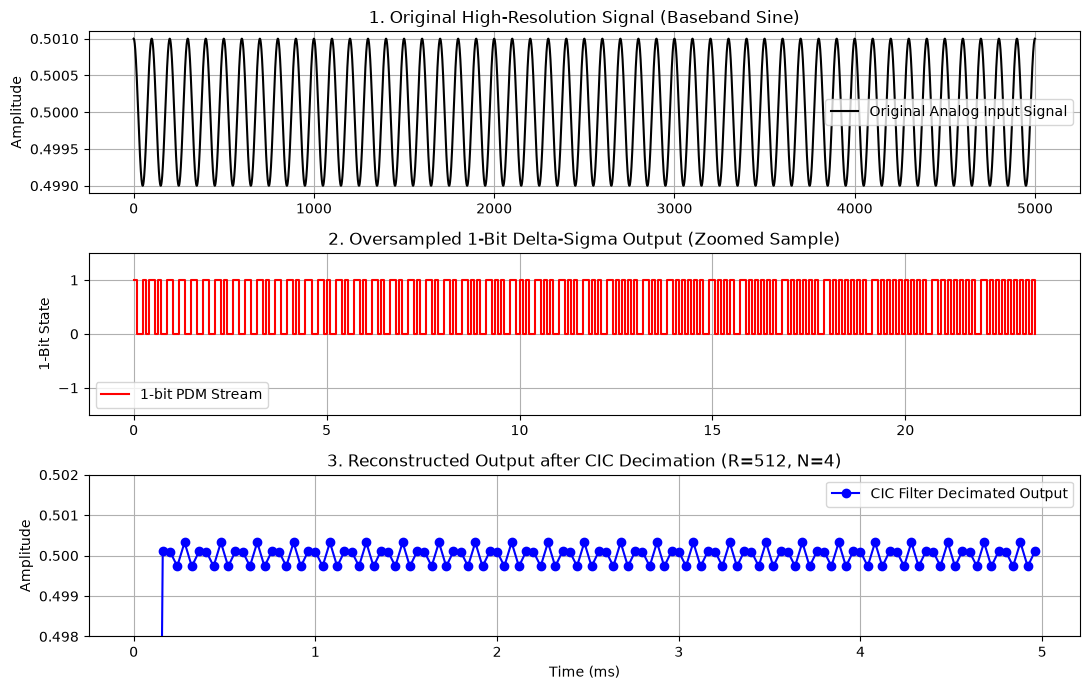

In [68]:
# 6. Plotting Results
t_decimated = np.arange(len(cic_output_scaled)) / (fs_high / R)

settled_output = cic_output_scaled[100:]

# 2. Extract DC offset (mean)
v_dc = np.mean(settled_output)

# 3. Calculate AC RMS value
v_ac_rms = np.sqrt(np.mean((settled_output - v_dc)**2))

# 4. Reconstruct true peak amplitude (A_peak = RMS * sqrt(2))
v_ac_peak = v_ac_rms * np.sqrt(2)

# 5. Calculate true positive and negative peaks
pos_peak = v_dc + v_ac_peak
neg_peak = v_dc - v_ac_peak
p2p_val  = 2 * v_ac_peak

print(f"DC Offset:     {v_dc:.6f} V")
print(f"Positive Peak: {pos_peak:.6f} V")
print(f"Negative Peak: {neg_peak:.6f} V")
print(f"True Peak-Peak:{p2p_val:.6f} V")
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)

# Plot 1: Analog Input
axes[0].plot(t_high * 1000000, input_sine, label="Original Analog Input Signal", color="black")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("1. Original High-Resolution Signal (Baseband Sine)")
axes[0].grid(True)
axes[0].legend()

# Plot 2: 1-Bit Delta-Sigma Output (Pulse Density)
axes[1].step(t_high[:300] * 1000000, bitstream[:300], color="red", where="post", label="1-bit PDM Stream")
axes[1].set_ylabel("1-Bit State")
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_title("2. Oversampled 1-Bit Delta-Sigma Output (Zoomed Sample)")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Reconstructed Signal from CIC Decimator
axes[2].plot(t_decimated * 1000, cic_output_scaled, 'o-', color="blue", label="CIC Filter Decimated Output")
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("Amplitude")
axes[2].set_title(f"3. Reconstructed Output after CIC Decimation (R={R}, N={N})")
axes[2].grid(True)
axes[2].legend()
axes[2].set_ylim(0.1, 0.9)
axes[2].set_ylim(0.498,0.502)

# print(len(t_decimated))

# print(f'stage 1 p-p value: {cic_filter.calculate_clean_peak_to_peak(cic_output_scaled, t_decimated, 0.004)}')

plt.tight_layout()
plt.show()